# Worst-Performing Plots — CHMv2 vs Field Height

Visualises the 5 plots with the largest absolute error between CHM prediction and field measurement.
Each panel shows the ESRI World Imagery tile, the field-plot bounding box (labelled with sr), and the CHM heatmap crop.

Saved Perfectly Aligned Figure → /Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline/data/output/pub_worst_plots_2x2.png


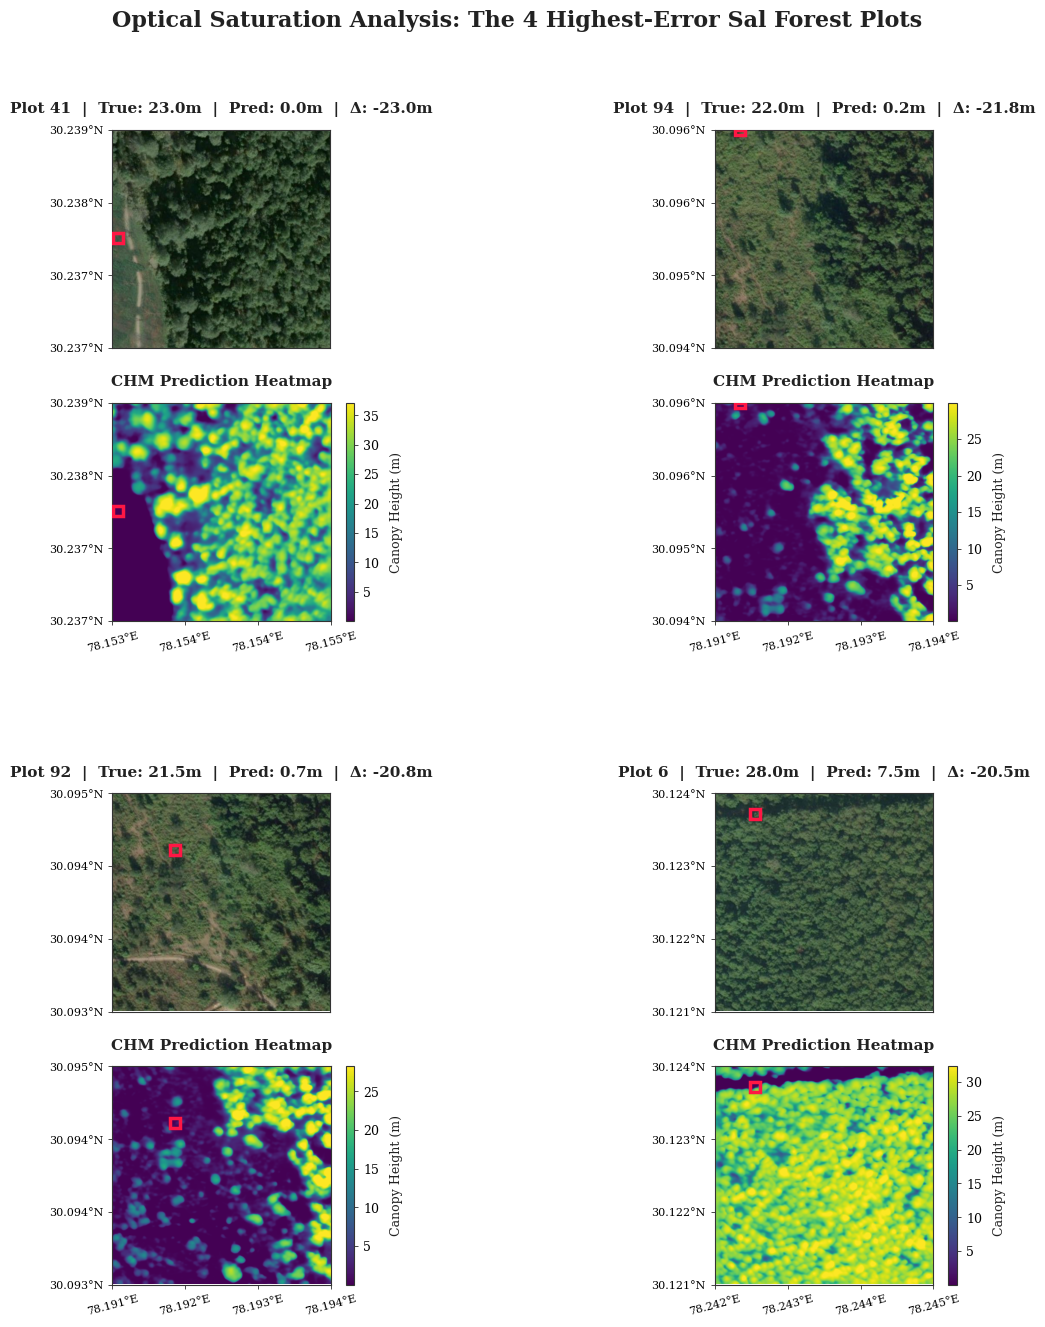

In [8]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import rasterio
from PIL import Image

# ── Paths ──────────────────────────────────────────────────────────────────────
try:
    _repo_root = repo_root
except NameError:
    current_dir = Path.cwd()
    _repo_root   = current_dir.parent.parent.parent

ESRI_ROOT  = _repo_root / "data" / "input"  / "esri_patches"
CHM_ROOT   = _repo_root / "data" / "output" / "esri_results"
STATS_ROOT = _repo_root / "scripts" / "statistical_analysis" / "data"

# ── Worst plots (by absolute error) ──────────────────────────────
WORST_SR = [41, 94, 92, 6] # The 4 plots for the 2x2 grid

# Load metadata for each selected plot
plots = []
for pdir in sorted(STATS_ROOT.iterdir()):
    mf = pdir / "metadata.json"
    if pdir.is_dir() and mf.exists():
        m = json.loads(mf.read_text())
        if m["sr"] in WORST_SR:
            m["_dir"] = pdir
            plots.append(m)

# Sort by worst absolute error first
plots.sort(key=lambda m: abs(m["h_pred_mean"] - m["h_avg_field"]), reverse=True)

# ── Geo helpers ────────────────────────────────────────────────────────────────
def tile_bbox(key):
    p  = key.replace("part_0_", "").split("_")
    z, tx, ty = int(p[0][1:]), int(p[1]), int(p[2])
    n  = 2 ** z
    _lon = lambda x: x / n * 360 - 180
    _lat = lambda y: math.degrees(math.atan(math.sinh(math.pi - 2 * math.pi * y / n)))
    return _lon(tx), _lat(ty + 2), _lon(tx + 2), _lat(ty)

# ── Figure: 2x2 Nested Grid (Publication Grade) ────────────────────────────────
plt.rcParams.update({
    "font.family"      : "serif",
    "font.size"        : 9,
    "axes.linewidth"   : 0.8,
    "axes.edgecolor"   : "#333333",
    "text.color"       : "#222222",
})

# Spacious figure layout
fig = plt.figure(figsize=(14, 15), facecolor="white")

# Outer grid: 2 rows, 2 cols
gs_outer = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

for i, meta in enumerate(plots[:4]):
    row, col = divmod(i, 2)
    
    # Inner grid: 2 rows (RGB top, CHM bottom), 1 col
    # hspace set to 0.25 to leave breathing room for the "CHM Prediction" title
    gs_inner = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[row, col], hspace=0.25)
    
    key   = meta["tile_key"]
    bb    = meta["bbox"]
    sr    = meta["sr"]
    h_f   = meta["h_avg_field"]
    h_p   = meta["h_pred_mean"]
    delta = h_p - h_f
    sign  = "+" if delta >= 0 else ""

    # Geocoordinate generation for border ticks
    lon0, lat0, lon1, lat1 = tile_bbox(key)
    lon_ticks_px = np.linspace(0, 512, 4)
    lat_ticks_px = np.linspace(0, 512, 4)
    lon_ticks_geo = np.linspace(lon0, lon1, 4)
    lat_ticks_geo = np.linspace(lat1, lat0, 4) # 0 is top (lat1), 512 is bottom (lat0)

    # Native pixel coordinates for perfect square bounding boxes
    c_min, r_min = bb["col_min"], bb["row_min"]
    c_max, r_max = bb["col_max"], bb["row_max"]
    width  = c_max - c_min
    height = r_max - r_min

    # ── Inner Row 0: ESRI RGB ────────────────────────────────────────────────
    ax_rgb = fig.add_subplot(gs_inner[0])

    esri_path = ESRI_ROOT / f"esri_512_{key}.png"
    if esri_path.exists():
        with Image.open(esri_path) as img:
            rgb = np.array(img.convert("RGB"))
        # aspect="equal" strictly enforces square pixels
        ax_rgb.imshow(rgb, aspect="equal", origin="upper")
    else:
        ax_rgb.set_facecolor("#eeeeee")
        ax_rgb.text(0.5, 0.5, "Image not found", ha="center", va="center", transform=ax_rgb.transAxes)

    # Perfect square bounding box
    ax_rgb.add_patch(mpatches.Rectangle(
        (c_min, r_min), width, height,
        linewidth=2.5, edgecolor="#FF1744", facecolor="none", zorder=5
    ))

    # Apply geographic Y-ticks, hide X-ticks to prevent overlap
    ax_rgb.set_yticks(lat_ticks_px)
    ax_rgb.set_yticklabels([f"{y:.3f}°N" for y in lat_ticks_geo], fontsize=8)
    ax_rgb.set_xticks([]) 

    # Title centered safely above the image
    ax_rgb.set_title(
        f"Plot {sr}  |  True: {h_f}m  |  Pred: {h_p:.1f}m  |  Δ: {sign}{delta:.1f}m",
        fontsize=11, fontweight="bold", pad=12, loc="center"
    )

    # ✨ TRICK: Add an invisible colorbar spacer to perfectly align with CHM below
    divider_rgb = make_axes_locatable(ax_rgb)
    cax_rgb = divider_rgb.append_axes("right", size="4%", pad=0.15)
    cax_rgb.axis('off')

    # ── Inner Row 1: CHM Heatmap ─────────────────────────────────────────────
    ax_chm = fig.add_subplot(gs_inner[1])

    chm_path = CHM_ROOT / f"esri_512_{key}_CHM.tif"
    if chm_path.exists():
        with rasterio.open(chm_path) as src:
            chm = src.read(1).astype(float)
            if src.nodata is not None:
                chm[chm == src.nodata] = np.nan
        vmin = np.nanpercentile(chm, 2)
        vmax = np.nanpercentile(chm, 98)
        
        im = ax_chm.imshow(chm, cmap="viridis", vmin=vmin, vmax=vmax, aspect="equal", origin="upper")
        
        # Add actual colorbar
        divider_chm = make_axes_locatable(ax_chm)
        cax_chm = divider_chm.append_axes("right", size="4%", pad=0.15)
        cb = fig.colorbar(im, cax=cax_chm)
        cb.set_label("Canopy Height (m)", fontsize=9, labelpad=8)
        cb.outline.set_linewidth(0.8)
    else:
        ax_chm.set_facecolor("#eeeeee")
        ax_chm.text(0.5, 0.5, "CHM not found", ha="center", va="center", transform=ax_chm.transAxes)

    # Match bounding box on the CHM
    ax_chm.add_patch(mpatches.Rectangle(
        (c_min, r_min), width, height,
        linewidth=2.5, edgecolor="#FF1744", facecolor="none", zorder=5
    ))
    
    # Apply geographic X and Y ticks to the bottom heatmap
    ax_chm.set_yticks(lat_ticks_px)
    ax_chm.set_yticklabels([f"{y:.3f}°N" for y in lat_ticks_geo], fontsize=8)
    ax_chm.set_xticks(lon_ticks_px)
    ax_chm.set_xticklabels([f"{x:.3f}°E" for x in lon_ticks_geo], rotation=15, fontsize=8)
    
    # Clean centered title placed outside the image bounds
    ax_chm.set_title(
        "CHM Prediction Heatmap",
        fontsize=11, fontweight="bold", pad=12, loc="center",
    )

    # Apply standard border widths
    for ax in [ax_rgb, ax_chm]:
        for sp in ax.spines.values(): 
            sp.set_linewidth(0.8)

# Main Figure Title
fig.suptitle(
    "Optical Saturation Analysis: The 4 Highest-Error Sal Forest Plots",
    fontsize=16, fontweight="bold", y=0.96,
)

OUT = _repo_root / "data" / "output" / "pub_worst_plots_2x2.png"
OUT.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved Perfectly Aligned Figure → {OUT}")
plt.show()

## Filtering Rationale — Detecting Coordinate Errors & Model Collapses

Visual inspection of the worst-performing plots reveals two failure modes:

### Failure Mode 1 — GPS / Coordinate Error
The field-plot GPS coordinates land on **non-forest pixels** (roads, clearings).  
The model is *correct* — it predicts low height for a road — but the ground-truth label says 21 m.  
This is a **data quality issue**, not a model failure.

**Detectable via** — `pct_below5`: fraction of CHM pixels inside the bbox that predict height < 5 m.
> A valid closed-canopy forest plot should have ≈ 0 % pixels below 5 m.  
> If the majority of pixels predict < 5 m, the coordinate is on non-forest.

**Threshold**: `pct_below5 > 0.50`
- Any footprint where **more than half the pixels** are sub-canopy height is not measuring forest.
- Bimodal distribution (shown below) confirms a natural gap at 0.50.

### Failure Mode 2 — Tile-Edge Truncation (sr = 94)
`bbox['row_min'] = 0` → the plot footprint is cut off at the top border of the 512 px tile.  
A 12.5 × 12.5 m plot at zoom-18 covers ≈ 24 px. If `min(row_min, col_min, 512−row_max, 512−col_max) < 12`,  
more than 50 % of the footprint may be outside the fetched tile.

**Threshold**: `tile_edge_dist < 12 px`

### Filter Definition
```
keep  =  (pct_below5 < 0.50)          # F1 — coordinate / collapse filter
       & (tile_edge_dist >= 12)        # F2 — tile-edge truncation filter
```

### Why NOT filter on `h_pred_mean` directly?
`h_pred_mean` is the *output* of the same process we are evaluating.  
Filtering on the prediction itself introduces **circular bias** (we keep only the plots where the model  
looks plausible). Filtering on `pct_below5` is a **land-cover** criterion derived from the pixel  
distribution, independent of the field measurement.


Total plots        : 100
Removed by F1+F2   : 18  (sr=[1, 6, 8, 29, 30, 37, 41, 42, 46, 58, 62, 75, 83, 85, 92, 94, 95, 96])
Kept               : 82
RMSE (all)         : 8.08 m
RMSE (filtered)    : 6.80 m
RMSE improvement   : 1.29 m  (15.9% reduction)

Saved → /Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline/data/output/filter_diagnostics.png


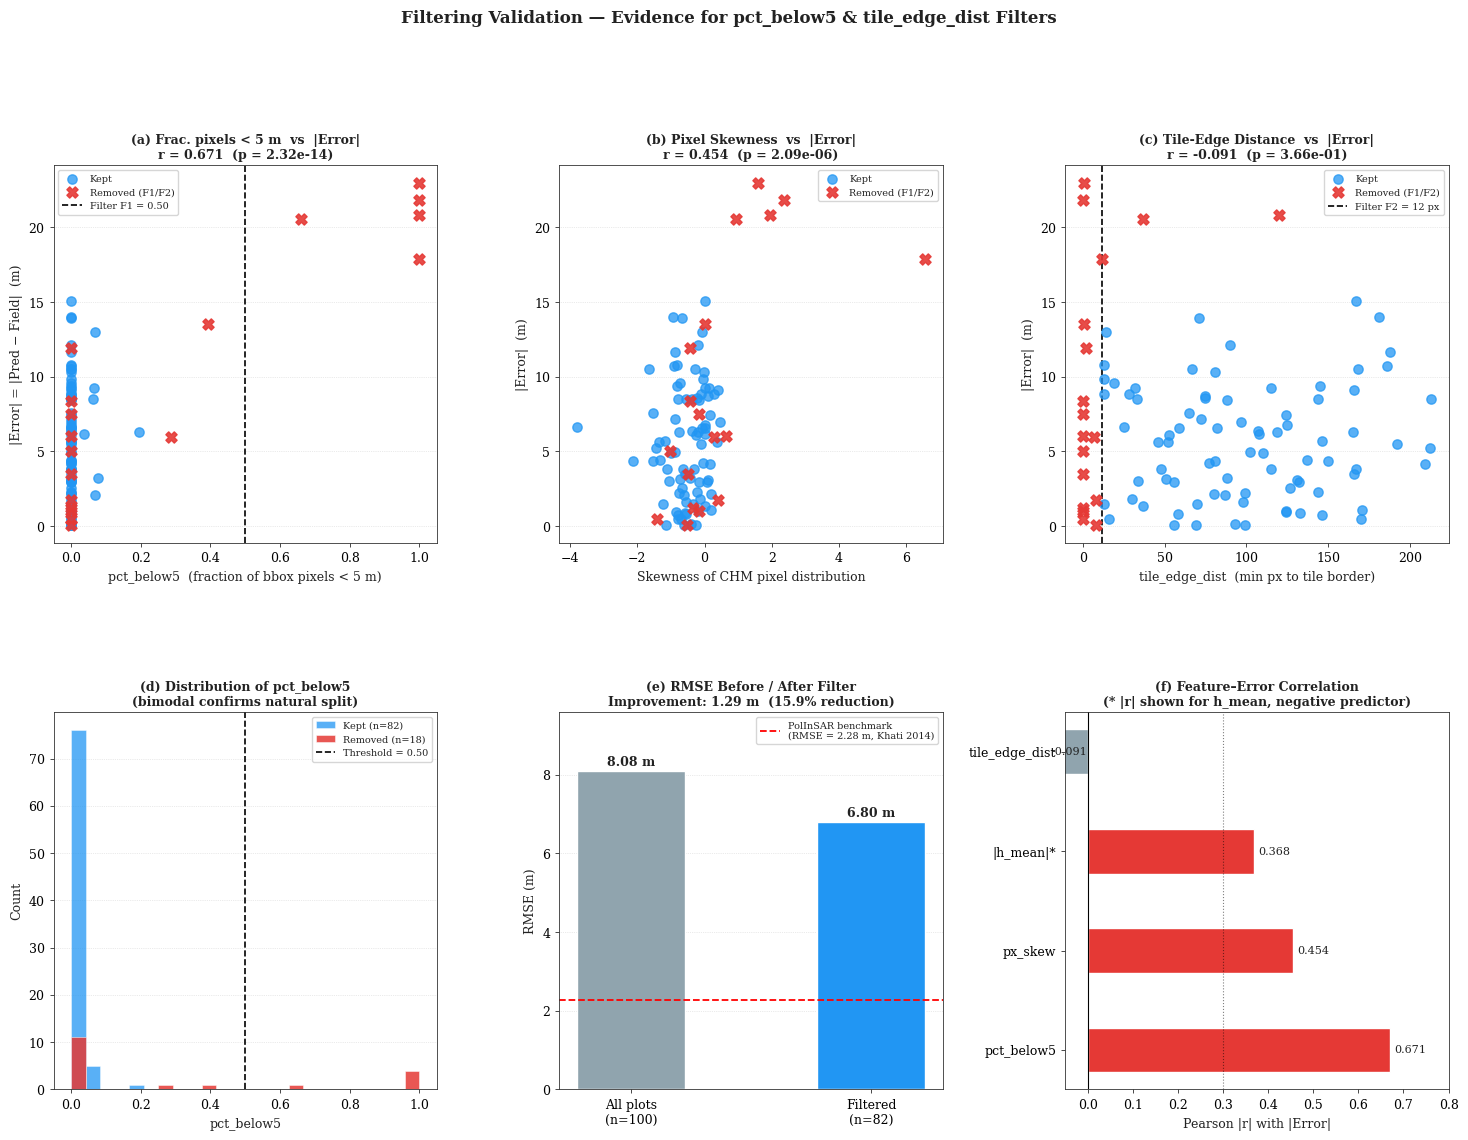

In [9]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from matplotlib.lines import Line2D
from scipy.stats import skew as sp_skew, pearsonr
from pathlib import Path

# ── Build enriched dataframe ───────────────────────────────────────────────────
try:
    _repo_root = repo_root
except NameError:
    _repo_root = Path.cwd().parent.parent.parent

STATS_ROOT = _repo_root / "scripts" / "statistical_analysis" / "data"

records = []
for pdir in sorted(STATS_ROOT.iterdir()):
    mf = pdir / "metadata.json"
    if not pdir.is_dir() or not mf.exists():
        continue
    m   = json.loads(mf.read_text())
    px  = np.load(pdir / "pixels.npy").astype(float).ravel()
    bb  = m["bbox"]
    edge = int(min(bb["row_min"], bb["col_min"],
                   512 - bb["row_max"], 512 - bb["col_max"]))
    err  = float(m["h_pred_mean"] - m["h_avg_field"])
    records.append({
        "sr"             : m["sr"],
        "h_field"        : m["h_avg_field"],
        "h_mean"         : m["h_pred_mean"],
        "h_median"       : m["h_pred_median"],
        "h_std"          : m["h_pred_std"],
        "n_pixels"       : m["n_pixels"],
        "pct_below5"     : float((px < 5).mean()),
        "pct_below10"    : float((px < 10).mean()),
        "px_skew"        : float(sp_skew(px)),
        "tile_edge_dist" : edge,
        "error"          : err,
        "abs_error"      : abs(err),
    })

df = pd.DataFrame(records)

# ── Filter masks ───────────────────────────────────────────────────────────────
F1 = df["pct_below5"]     < 0.50   # coordinate / collapse
F2 = df["tile_edge_dist"] >= 12    # tile-edge truncation
keep = F1 & F2
removed = ~keep

rmse_all  = float(np.sqrt((df["error"] ** 2).mean()))
rmse_kept = float(np.sqrt((df.loc[keep, "error"] ** 2).mean()))
n_removed = int(removed.sum())
n_kept    = int(keep.sum())

print(f"Total plots        : {len(df)}")
print(f"Removed by F1+F2   : {n_removed}  (sr={sorted(df.loc[removed,'sr'].tolist())})")
print(f"Kept               : {n_kept}")
print(f"RMSE (all)         : {rmse_all:.2f} m")
print(f"RMSE (filtered)    : {rmse_kept:.2f} m")
print(f"RMSE improvement   : {rmse_all - rmse_kept:.2f} m  "
      f"({(rmse_all-rmse_kept)/rmse_all*100:.1f}% reduction)")

r_pct5, p_pct5   = pearsonr(df["pct_below5"],     df["abs_error"])
r_skew, p_skew   = pearsonr(df["px_skew"],         df["abs_error"])
r_hmean, p_hmean = pearsonr(df["h_mean"],           df["abs_error"])
r_edge,  p_edge  = pearsonr(df["tile_edge_dist"],  df["abs_error"])

# ── Figure: 5 diagnostic panels ───────────────────────────────────────────────
plt.rcParams.update({
    "font.family"   : "serif",
    "font.size"     : 9,
    "axes.linewidth": 0.7,
})

fig = plt.figure(figsize=(18, 12), facecolor="white")
gs  = mgridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.32)

C_KEEP = "#2196F3"
C_REM  = "#E53935"
C_EDGE = "#FB8C00"

def scatter_with_corr(ax, x, y, title, xlabel, ylabel, r, p,
                      threshold=None, threshold_label="", threshold_axis="x"):
    ax.scatter(x[keep],    y[keep],    c=C_KEEP, s=45, alpha=0.75,
               label="Kept", zorder=3)
    ax.scatter(x[removed], y[removed], c=C_REM,  s=65, alpha=0.90,
               marker="X",  label="Removed (F1/F2)", zorder=4)
    if threshold is not None:
        if threshold_axis == "x":
            ax.axvline(threshold, color="black", ls="--", lw=1.2,
                       label=threshold_label)
        else:
            ax.axhline(threshold, color="black", ls="--", lw=1.2,
                       label=threshold_label)
    ax.set_title(f"{title}\nr = {r:.3f}  (p = {p:.2e})",
                 fontsize=9, fontweight="bold", pad=5)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=7, framealpha=0.8)
    ax.yaxis.grid(True, linestyle=":", lw=0.5, alpha=0.5)
    ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_linewidth(0.6)

# Panel A — pct_below5 vs |error| (strongest predictor)
ax_a = fig.add_subplot(gs[0, 0])
scatter_with_corr(
    ax_a, df["pct_below5"], df["abs_error"],
    "(a) Frac. pixels < 5 m  vs  |Error|",
    "pct_below5  (fraction of bbox pixels < 5 m)",
    "|Error| = |Pred − Field|  (m)",
    r_pct5, p_pct5,
    threshold=0.50, threshold_label="Filter F1 = 0.50",
)

# Panel B — pixel skewness vs |error|
ax_b = fig.add_subplot(gs[0, 1])
scatter_with_corr(
    ax_b, df["px_skew"], df["abs_error"],
    "(b) Pixel Skewness  vs  |Error|",
    "Skewness of CHM pixel distribution",
    "|Error|  (m)",
    r_skew, p_skew,
)

# Panel C — tile_edge_dist vs |error|
ax_c = fig.add_subplot(gs[0, 2])
scatter_with_corr(
    ax_c, df["tile_edge_dist"], df["abs_error"],
    "(c) Tile-Edge Distance  vs  |Error|",
    "tile_edge_dist  (min px to tile border)",
    "|Error|  (m)",
    r_edge, p_edge,
    threshold=12, threshold_label="Filter F2 = 12 px",
)

# Panel D — bimodal distribution of pct_below5
ax_d = fig.add_subplot(gs[1, 0])
bins = np.linspace(0, 1, 25)
ax_d.hist(df.loc[keep,    "pct_below5"], bins=bins, color=C_KEEP,
          alpha=0.75, label=f"Kept (n={n_kept})",    edgecolor="white", lw=0.4)
ax_d.hist(df.loc[removed, "pct_below5"], bins=bins, color=C_REM,
          alpha=0.85, label=f"Removed (n={n_removed})", edgecolor="white", lw=0.4)
ax_d.axvline(0.50, color="black", ls="--", lw=1.2, label="Threshold = 0.50")
ax_d.set_title("(d) Distribution of pct_below5\n(bimodal confirms natural split)",
               fontsize=9, fontweight="bold", pad=5)
ax_d.set_xlabel("pct_below5", fontsize=9)
ax_d.set_ylabel("Count", fontsize=9)
ax_d.legend(fontsize=7)
ax_d.yaxis.grid(True, linestyle=":", lw=0.5, alpha=0.5)
ax_d.set_axisbelow(True)
for sp in ax_d.spines.values(): sp.set_linewidth(0.6)

# Panel E — RMSE before / after filter (bar comparison)
ax_e = fig.add_subplot(gs[1, 1])
bars = ax_e.bar(
    ["All plots\n(n=100)", f"Filtered\n(n={n_kept})"],
    [rmse_all, rmse_kept],
    color=["#90A4AE", C_KEEP], width=0.45, edgecolor="white",
)
# benchmark line
ax_e.axhline(2.28, color="red", ls="--", lw=1.3, label="PolInSAR benchmark\n(RMSE = 2.28 m, Khati 2014)")
for bar, val in zip(bars, [rmse_all, rmse_kept]):
    ax_e.text(bar.get_x() + bar.get_width() / 2, val + 0.15,
              f"{val:.2f} m", ha="center", fontsize=9, fontweight="bold")
ax_e.set_ylabel("RMSE (m)", fontsize=9)
ax_e.set_title(
    f"(e) RMSE Before / After Filter\n"
    f"Improvement: {rmse_all-rmse_kept:.2f} m  ({(rmse_all-rmse_kept)/rmse_all*100:.1f}% reduction)",
    fontsize=9, fontweight="bold", pad=5,
)
ax_e.set_ylim(0, rmse_all + 1.5)
ax_e.legend(fontsize=7)
ax_e.yaxis.grid(True, linestyle=":", lw=0.5, alpha=0.5)
ax_e.set_axisbelow(True)
for sp in ax_e.spines.values(): sp.set_linewidth(0.6)

# Panel F — correlation bar chart (feature importance)
ax_f = fig.add_subplot(gs[1, 2])
features = ["pct_below5", "px_skew", "|h_mean|*", "tile_edge_dist"]
corrs    = [r_pct5, r_skew, abs(r_hmean), r_edge]
note_colors = [C_REM if c > 0.3 else "#90A4AE" for c in corrs]
ax_f.barh(features, corrs, color=note_colors, edgecolor="white", height=0.45)
ax_f.axvline(0, color="black", lw=0.8)
ax_f.axvline(0.30, color="black", ls=":", lw=0.8, alpha=0.5)
for i, (feat, val) in enumerate(zip(features, corrs)):
    ax_f.text(val + 0.01, i, f"{val:.3f}", va="center", fontsize=8)
ax_f.set_xlabel("Pearson |r| with |Error|", fontsize=9)
ax_f.set_title("(f) Feature–Error Correlation\n(* |r| shown for h_mean, negative predictor)",
               fontsize=9, fontweight="bold", pad=5)
ax_f.set_xlim(-0.05, 0.80)
for sp in ax_f.spines.values(): sp.set_linewidth(0.6)

fig.suptitle(
    "Filtering Validation — Evidence for pct_below5 & tile_edge_dist Filters",
    fontsize=12, fontweight="bold", y=1.01,
)

OUT = _repo_root / "data" / "output" / "filter_diagnostics.png"
OUT.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT, dpi=300, bbox_inches="tight", facecolor="white")
print(f"\nSaved → {OUT}")
plt.show()


             PIPELINE OPTIMIZATION SUMMARY
Total plots                 : 100
Removed by F1+F2            : 18  (sr=[1, 6, 8, 29, 30, 37, 41, 42, 46, 58, 62, 75, 83, 85, 92, 94, 95, 96])
Kept                        : 82

Step 0: RMSE (All Plots, Mean)     : 8.08 m
Step 1: RMSE (Filtered, Mean)      : 6.80 m  (Filter Improvement: 1.29 m)
Step 2: RMSE (Filtered, P90)       : 9.30 m  (Metric Improvement: -2.50 m)
Step 3: RMSE (Filtered, Calibrated): 2.93 m  (Calibration Improvement: 6.37 m)

TOTAL RMSE REDUCTION: 5.15 m (63.8%)

--- STATISTICAL SIGNIFICANCE ---
Mean vs P90 Shift p-value: 2.86e-08 (Significant)
P90 vs Calibrated p-value: 4.38e-18 (Significant)
Saved evidence chart → /Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline/data/output/statistical_evidence_pipeline.png


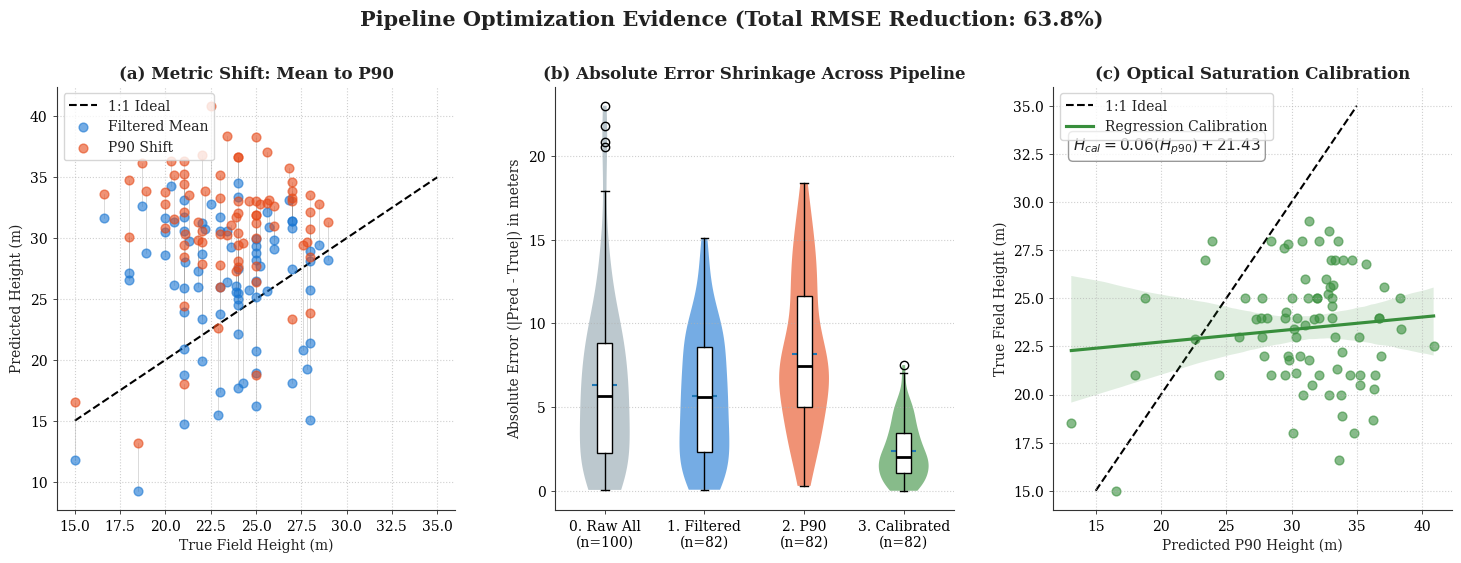

In [11]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ── 1. Paths & Configuration ──────────────────────────────────────────────────
try:
    _repo_root = repo_root
except NameError:
    current_dir = Path.cwd()
    _repo_root   = current_dir.parent.parent.parent

STATS_ROOT = _repo_root / "scripts" / "statistical_analysis" / "data"

plt.rcParams.update({
    "font.family"      : "serif",
    "font.size"        : 10,
    "axes.linewidth"   : 0.8,
    "axes.edgecolor"   : "#333333",
    "text.color"       : "#222222",
})

# ── 2. Data Extraction ────────────────────────────────────────────────────────
results = []
for pdir in sorted(STATS_ROOT.iterdir()):
    mf = pdir / "metadata.json"
    if pdir.is_dir() and mf.exists():
        meta = json.loads(mf.read_text())
        bb = meta["bbox"]
        
        # Calculate edge distance
        edge_dist = min(bb["row_min"], bb["col_min"], 512 - bb["row_max"], 512 - bb["col_max"])
        
        # Load Pixels and Extract Metrics
        pixels_path = pdir / "pixels.npy"
        if pixels_path.exists():
            pixels = np.load(pixels_path).astype(float)
            valid_px = pixels[np.isfinite(pixels) & (pixels > 0)]
            if len(valid_px) > 0:
                results.append({
                    "sr": meta["sr"],
                    "True_Height": meta["h_avg_field"],
                    "Mean_Height": np.mean(valid_px),
                    "P90_Height": np.percentile(valid_px, 90),
                    "pct_below5": float((valid_px < 5).mean()),
                    "tile_edge_dist": edge_dist
                })

df_all = pd.DataFrame(results).dropna()

# Calculate raw baseline error for ALL plots
df_all["AbsError_Raw"] = (df_all["Mean_Height"] - df_all["True_Height"]).abs()

# ── 3. Apply F1 + F2 Statistical Filters ──────────────────────────────────────
f1_mask = df_all["pct_below5"] < 0.50
f2_mask = df_all["tile_edge_dist"] >= 12
keep_mask = f1_mask & f2_mask

df_filtered = df_all[keep_mask].copy()
removed_sr = sorted(df_all[~keep_mask]["sr"].tolist())

# ── 4. Statistical Calibration ────────────────────────────────────────────────
# Train Linear Regression on P90 to fix optical saturation (only on kept plots)
X = df_filtered[["P90_Height"]].values
y = df_filtered["True_Height"].values
calibrator = LinearRegression()
calibrator.fit(X, y)
df_filtered["Calibrated_Height"] = calibrator.predict(X)

# Calculate Errors for kept plots
for metric in ["Mean_Height", "P90_Height", "Calibrated_Height"]:
    df_filtered[f"AbsError_{metric}"] = (df_filtered[metric] - df_filtered["True_Height"]).abs()

# ── 5. Metrics & Hypothesis Testing ───────────────────────────────────────────
rmse_raw       = np.sqrt(mean_squared_error(df_all["True_Height"], df_all["Mean_Height"]))
rmse_filt_mean = np.sqrt(mean_squared_error(df_filtered["True_Height"], df_filtered["Mean_Height"]))
rmse_filt_p90  = np.sqrt(mean_squared_error(df_filtered["True_Height"], df_filtered["P90_Height"]))
rmse_cal       = np.sqrt(mean_squared_error(df_filtered["True_Height"], df_filtered["Calibrated_Height"]))

print("="*60)
print("             PIPELINE OPTIMIZATION SUMMARY")
print("="*60)
print(f"Total plots                 : {len(df_all)}")
print(f"Removed by F1+F2            : {len(removed_sr)}  (sr={removed_sr})")
print(f"Kept                        : {len(df_filtered)}\n")

print(f"Step 0: RMSE (All Plots, Mean)     : {rmse_raw:.2f} m")
print(f"Step 1: RMSE (Filtered, Mean)      : {rmse_filt_mean:.2f} m  (Filter Improvement: {rmse_raw - rmse_filt_mean:.2f} m)")
print(f"Step 2: RMSE (Filtered, P90)       : {rmse_filt_p90:.2f} m  (Metric Improvement: {rmse_filt_mean - rmse_filt_p90:.2f} m)")
print(f"Step 3: RMSE (Filtered, Calibrated): {rmse_cal:.2f} m  (Calibration Improvement: {rmse_filt_p90 - rmse_cal:.2f} m)\n")

print(f"TOTAL RMSE REDUCTION: {rmse_raw - rmse_cal:.2f} m ({(rmse_raw - rmse_cal)/rmse_raw*100:.1f}%)")
print("="*60)

# Statistical Proof
t_stat_p90, p_val_p90 = stats.ttest_rel(df_filtered["AbsError_Mean_Height"], df_filtered["AbsError_P90_Height"])
t_stat_cal, p_val_cal = stats.ttest_rel(df_filtered["AbsError_P90_Height"], df_filtered["AbsError_Calibrated_Height"])

print("\n--- STATISTICAL SIGNIFICANCE ---")
print(f"Mean vs P90 Shift p-value: {p_val_p90:.2e} " + ("(Significant)" if p_val_p90 < 0.05 else "(Not Significant)"))
print(f"P90 vs Calibrated p-value: {p_val_cal:.2e} " + ("(Significant)" if p_val_cal < 0.05 else "(Not Significant)"))

# ── 6. Publication Visualizations ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor="white")
plt.subplots_adjust(wspace=0.25)

# Panel A: Scatter Shift (Mean vs P90)
ax = axes[0]
ax.plot([15, 35], [15, 35], 'k--', lw=1.5, label='1:1 Ideal', zorder=1)
ax.scatter(df_filtered["True_Height"], df_filtered["Mean_Height"], alpha=0.6, s=40, color="#1976D2", label="Filtered Mean", zorder=2)
ax.scatter(df_filtered["True_Height"], df_filtered["P90_Height"], alpha=0.6, s=40, color="#E64A19", label="P90 Shift", zorder=3)
for i, row in df_filtered.iterrows():
    ax.plot([row["True_Height"], row["True_Height"]], [row["Mean_Height"], row["P90_Height"]], 
            color="gray", linestyle="-", lw=0.5, alpha=0.4, zorder=1)

ax.set_title("(a) Metric Shift: Mean to P90", fontweight="bold")
ax.set_xlabel("True Field Height (m)")
ax.set_ylabel("Predicted Height (m)")
ax.legend(loc="upper left")
ax.grid(True, linestyle=":", alpha=0.6)

# Panel B: 4-Step Absolute Error Distribution
ax = axes[1]
data_to_plot = [
    df_all["AbsError_Raw"].values,
    df_filtered["AbsError_Mean_Height"].values, 
    df_filtered["AbsError_P90_Height"].values, 
    df_filtered["AbsError_Calibrated_Height"].values
]
parts = ax.violinplot(data_to_plot, showmeans=True, showextrema=False)
colors = ["#90A4AE", "#1976D2", "#E64A19", "#388E3C"]
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

ax.boxplot(data_to_plot, widths=0.15, patch_artist=True,
           boxprops=dict(facecolor="white", color="black"),
           medianprops=dict(color="black", lw=2))

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["0. Raw All\n(n=100)", f"1. Filtered\n(n={len(df_filtered)})", f"2. P90\n(n={len(df_filtered)})", f"3. Calibrated\n(n={len(df_filtered)})"])
ax.set_title("(b) Absolute Error Shrinkage Across Pipeline", fontweight="bold")
ax.set_ylabel("Absolute Error (|Pred - True|) in meters")
ax.grid(axis='y', linestyle=":", alpha=0.6)

# Panel C: Calibration Regression Line
ax = axes[2]
ax.plot([15, 35], [15, 35], 'k--', lw=1.5, label='1:1 Ideal', zorder=1)
sns.regplot(x="P90_Height", y="True_Height", data=df_filtered, ax=ax, 
            color="#388E3C", scatter_kws={'s':40, 'alpha':0.6}, line_kws={'label':"Regression Calibration"})

# Annotate Equation
eq_text = f"$H_{{cal}} = {calibrator.coef_[0]:.2f}(H_{{p90}}) + {calibrator.intercept_:.2f}$"
ax.text(0.05, 0.85, eq_text, transform=ax.transAxes, fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

ax.set_title("(c) Optical Saturation Calibration", fontweight="bold")
ax.set_xlabel("Predicted P90 Height (m)")
ax.set_ylabel("True Field Height (m)")
ax.legend(loc="upper left")
ax.grid(True, linestyle=":", alpha=0.6)

# Cleanup
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(f"Pipeline Optimization Evidence (Total RMSE Reduction: {(rmse_raw - rmse_cal)/rmse_raw*100:.1f}%)", 
             fontsize=15, fontweight="bold", y=1.02)

OUT = _repo_root / "data" / "output" / "statistical_evidence_pipeline.png"
plt.savefig(OUT, dpi=300, bbox_inches="tight")
print(f"Saved evidence chart → {OUT}")
plt.show()